# NBA Game Outcome Prediction: Evaluation & Analysis


## setup

In [1]:
import pandas as pd
import numpy as np
import os

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss,
                             confusion_matrix, classification_report, roc_curve)
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 9, 'axes.grid': True, 'grid.alpha': 0.3,
                     'figure.dpi': 120, 'savefig.bbox': 'tight'})
C_HOME, C_AWAY = '#2E5C8A', '#C4553B'
os.makedirs('figs', exist_ok=True)

## load tuned predictions

In [2]:
pred = pd.read_csv('test_predictions.csv')
meta = pd.read_csv('model_meta.csv')
baseline_acc = float(open('baseline_acc.txt').read())

y_test = pred['y_true']
models = {'Logistic Regression':'lr_proba', 'Random Forest':'rf_proba', 'XGBoost':'xgb_proba'}
print('Test games:', len(pred))
print('Baseline (always home):', round(baseline_acc, 4))
meta

Test games: 2809
Baseline (always home): 0.5511


,model,best_params,cv_auc
0,LogisticRegression,{'C': 0.01},0.653481
1,RandomForest,"{'max_depth': 5, 'n_estimators': 400}",0.655833
2,XGBoost,"{'learning_rate': 0.03, 'max_depth': 3, 'n_est...",0.648789


## results table

Accuracy is the number to compare against the baseline. ROC-AUC compares the models without depending on the 0.5 threshold. Log-loss checks whether the predicted probabilities are trustworthy rather than just correctly ranked.

In [3]:
rows = [{'Model':'Baseline (home)', 'Accuracy':baseline_acc, 'ROC-AUC':0.5,
         'Log-loss':np.nan, 'F1':f1_score(y_test, np.ones(len(y_test)))}]

for name, col in models.items():
    proba = pred[col]
    p = (proba >= 0.5).astype(int)
    rows.append({'Model':name,
                 'Accuracy':accuracy_score(y_test, p),
                 'ROC-AUC':roc_auc_score(y_test, proba),
                 'Log-loss':log_loss(y_test, proba),
                 'F1':f1_score(y_test, p)})

results_df = pd.DataFrame(rows).set_index('Model').round(4)
results_df

,Accuracy,ROC-AUC,Log-loss,F1
Model,,,,
Baseline (home),0.5511,0.5000,NaN,0.7106
Logistic Regression,0.6444,0.6998,0.6237,0.7049
Random Forest,0.6419,0.6986,0.6294,0.7089
XGBoost,0.6429,0.6995,0.6254,0.6965


## results visualization

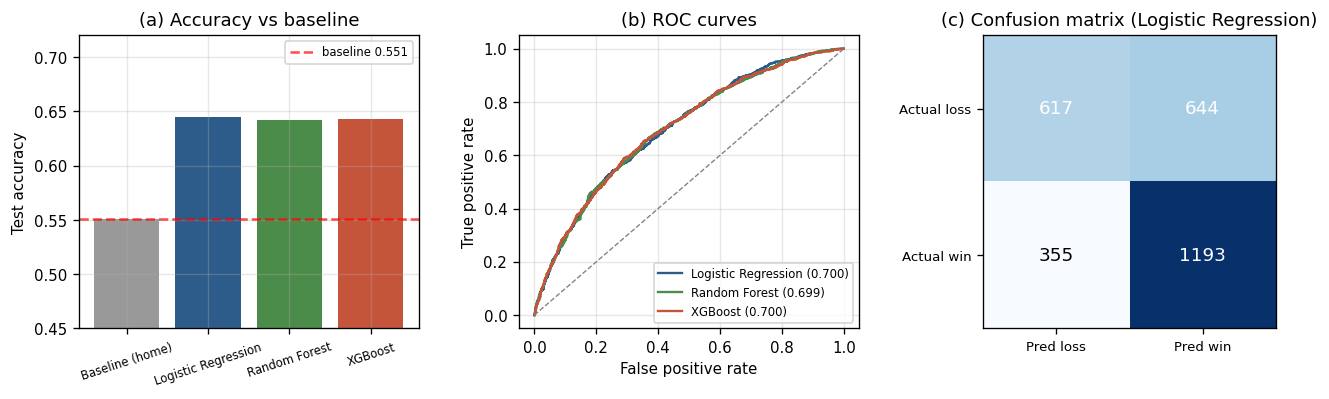

Best model by ROC-AUC: Logistic Regression


In [4]:
cmap3 = {'Logistic Regression':C_HOME, 'Random Forest':'#4C8C4A', 'XGBoost':C_AWAY}
fig, ax = plt.subplots(1, 3, figsize=(11, 3.4))

# (a) accuracy vs baseline
r = results_df.reset_index()
ax[0].bar(r['Model'], r['Accuracy'], color=['#999999', C_HOME, '#4C8C4A', C_AWAY])
ax[0].axhline(baseline_acc, ls='--', color='red', alpha=0.7, label=f'baseline {baseline_acc:.3f}')
ax[0].set_ylim(0.45, 0.72); ax[0].set_ylabel('Test accuracy')
ax[0].set_title('(a) Accuracy vs baseline')
ax[0].tick_params(axis='x', rotation=18, labelsize=7); ax[0].legend(fontsize=7)

# (b) ROC curves
for n, col in models.items():
    fpr, tpr, _ = roc_curve(y_test, pred[col])
    ax[1].plot(fpr, tpr, lw=1.4, color=cmap3[n], label=f'{n} ({roc_auc_score(y_test,pred[col]):.3f})')
ax[1].plot([0,1],[0,1], ls='--', color='gray', lw=0.8)
ax[1].set_xlabel('False positive rate'); ax[1].set_ylabel('True positive rate')
ax[1].set_title('(b) ROC curves'); ax[1].legend(fontsize=7, loc='lower right')

# (c) confusion matrix of best model
best_name = results_df.drop(index='Baseline (home)')['ROC-AUC'].idxmax()
best_pred = (pred[models[best_name]] >= 0.5).astype(int)
cm = confusion_matrix(y_test, best_pred)
ax[2].imshow(cm, cmap='Blues')
ax[2].set_xticks([0,1]); ax[2].set_xticklabels(['Pred loss','Pred win'], fontsize=8)
ax[2].set_yticks([0,1]); ax[2].set_yticklabels(['Actual loss','Actual win'], fontsize=8)
for i in range(2):
    for j in range(2):
        ax[2].text(j, i, cm[i,j], ha='center', va='center', fontsize=11,
                     color='white' if cm[i,j] > cm.max()/2 else 'black')
ax[2].set_title(f'(c) Confusion matrix ({best_name})'); ax[2].grid(False)

plt.tight_layout(); plt.savefig('figs/fig_results.pdf'); plt.show()
print('Best model by ROC-AUC:', best_name)

## confusion matrix & classification report (best model)

Precision, recall and F1 for the best model. The classes are close to balanced here, so accuracy is still the main number, but this shows the error breakdown per class.

In [5]:
print('Confusion matrix:')
print(pd.DataFrame(cm, index=['Actual Loss','Actual Win'], columns=['Pred Loss','Pred Win']))
print('\nClassification report:')
print(classification_report(y_test, best_pred, target_names=['Home Loss','Home Win']))

Confusion matrix:
             Pred Loss  Pred Win
Actual Loss        617       644
Actual Win         355      1193

Classification report:
              precision    recall  f1-score   support

   Home Loss       0.63      0.49      0.55      1261
    Home Win       0.65      0.77      0.70      1548

    accuracy                           0.64      2809
   macro avg       0.64      0.63      0.63      2809
weighted avg       0.64      0.64      0.64      2809

